# Heart Disease Prediction

Predicting whether a patient has heart disease from 13 clinical measurements (age, blood pressure, cholesterol, chest pain type, exercise test results...) and comparing five classification models.

## 1. Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart.csv')

In [3]:
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


In [4]:
df.shape

(303, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [6]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 2. Missing values and duplicates

In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df[df.duplicated(keep=False)]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


Two rows are identical in every column, so it's the same patient entered twice. I keep one.

In [10]:
df = df.drop_duplicates()

In [11]:
len(df)

302

## 3. Categorical columns

Most columns are codes rather than measurements. I check which values each one takes and compare them with the column descriptions (listed in the README).

In [12]:
for col in ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall', 'output']:
    print(df[col].value_counts().sort_index(), '\n')

sex
0     96
1    206
Name: count, dtype: int64 

cp
0    143
1     50
2     86
3     23
Name: count, dtype: int64 

fbs
0    257
1     45
Name: count, dtype: int64 

restecg
0    147
1    151
2      4
Name: count, dtype: int64 

exng
0    203
1     99
Name: count, dtype: int64 

slp
0     21
1    140
2    141
Name: count, dtype: int64 

caa
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64 

thall
0      2
1     18
2    165
3    117
Name: count, dtype: int64 

output
0    138
1    164
Name: count, dtype: int64 



Two columns have values that shouldn't exist:

- `caa` is the number of major blood vessels seen in the scan, which can only be 0–3. Four patients have **4**.
- `thall` is the thallium stress test result, which has three possible results (1, 2, 3). Two patients have **0**.

This data comes from the UCI Cleveland heart disease dataset, which reports 4 missing values in this vessels column and 2 in the thallium column. Those counts match, so 4 and 0 are how the missing values were stored in this version.

In [13]:
df[(df['caa'] == 4) | (df['thall'] == 0)]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
48,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1
92,52,1,2,138,223,0,1,169,0,0.0,2,4,2,1
158,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
251,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
281,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0


That's only 6 of 302 patients, so I drop them instead of guessing values.

In [14]:
df = df[(df['caa'] < 4) & (df['thall'] > 0)]

In [15]:
len(df)

296

## 4. Numeric columns and outliers

In [16]:
numeric = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

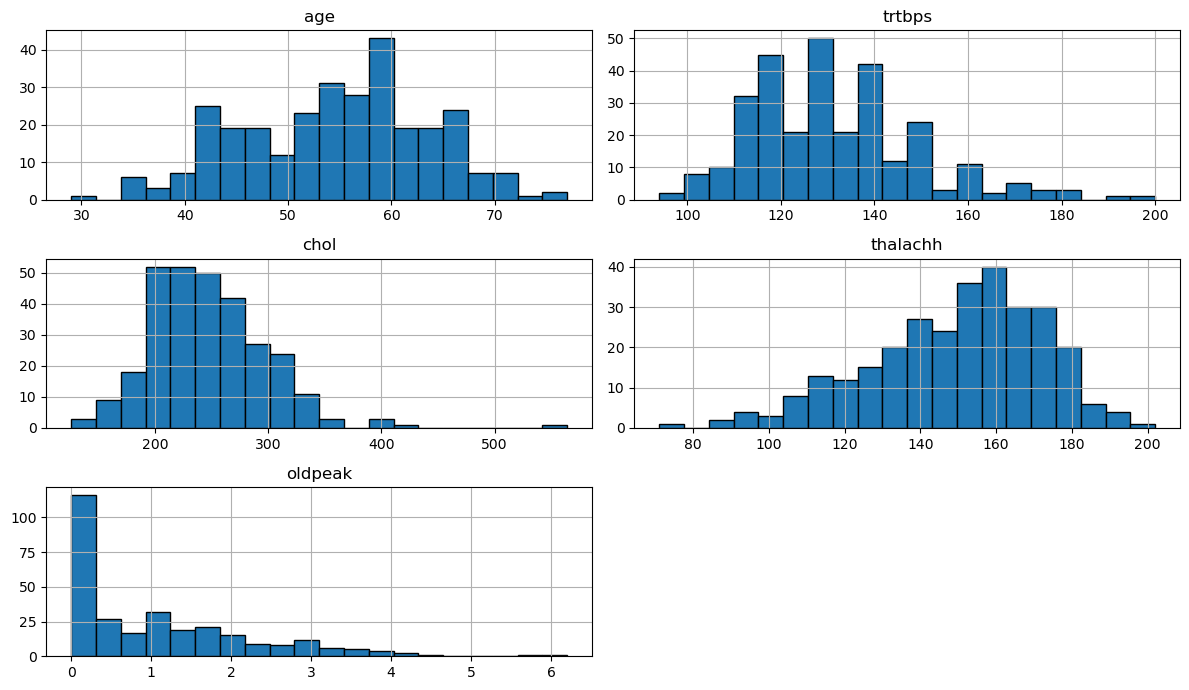

In [17]:
df[numeric].hist(bins=20, figsize=(12, 7), edgecolor='black')
plt.tight_layout()
plt.show()

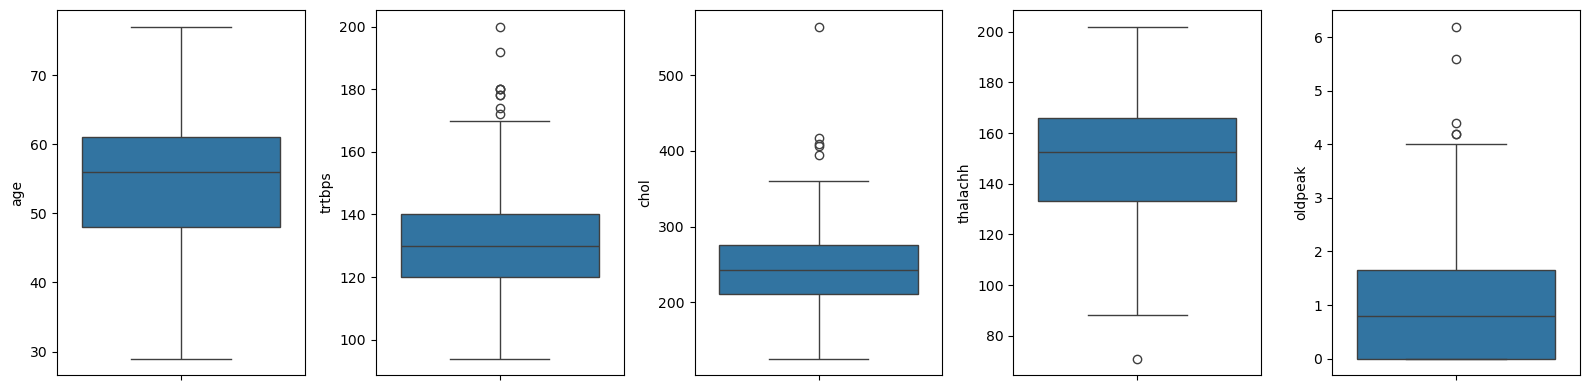

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, numeric):
    sns.boxplot(y=df[col], ax=ax)
plt.tight_layout()
plt.show()

Cholesterol, blood pressure, max heart rate and oldpeak all have points past the whiskers. I check those patients to see whether they're typos or just unusual.

In [19]:
df.nlargest(5, 'chol')

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
28,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
220,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0
96,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1


564 mg/dl is far above the rest, but it's a real (if rare) level, and the rest of that patient's measurements look normal. Not a typo.

In [20]:
df.nlargest(5, 'trtbps')

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
223,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
248,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
110,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
203,68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
266,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0


In [21]:
df.nsmallest(5, 'thalachh')

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
272,67,1,0,120,237,0,1,71,0,1.0,1,0,2,0
243,57,1,0,152,274,0,1,88,1,1.2,1,1,3,0
297,59,1,0,164,176,1,0,90,0,1.0,1,2,1,0
262,53,1,0,123,282,0,1,95,1,2.0,1,2,3,0
136,60,0,2,120,178,1,1,96,0,0.0,2,0,2,1


In [22]:
df.nlargest(5, 'oldpeak')

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
204,62,0,0,160,164,0,0,145,0,6.2,0,3,3,0
221,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
291,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
101,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1
250,51,1,0,140,298,0,1,122,1,4.2,1,3,3,0


A resting blood pressure of 200 and a max heart rate of 71 are extreme but medically possible, and most of these patients belong to the same group in `output`, which is what you'd expect from genuinely sick patients.

Unlike the house price data, nothing here is impossible (no blood pressure of 0, no prices typed into the wrong column). With fewer than 300 patients I keep all of them.

## 5. What does `output` mean?

The dataset page says 1 = more chance of heart attack. Before trusting that, I check it against the features that are known to go with heart disease.

In [23]:
df['output'].value_counts()

output
1    160
0    136
Name: count, dtype: int64

In [24]:
df.groupby('output')[['age', 'thalachh', 'oldpeak']].mean()

,age,thalachh,oldpeak
output,,,
0,56.735294,138.948529,1.600735
1,52.643750,158.581250,0.598750


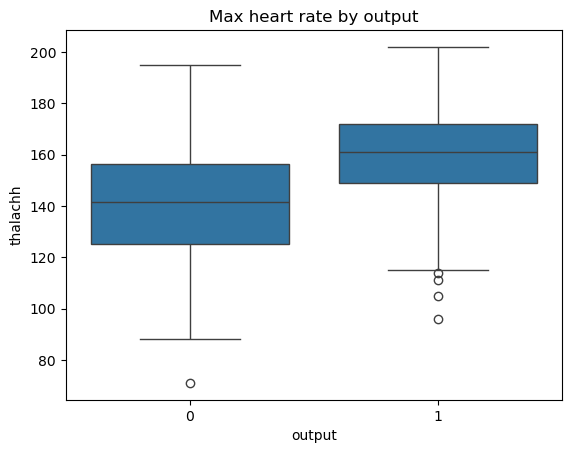

In [25]:
sns.boxplot(data=df, x='output', y='thalachh')
plt.title('Max heart rate by output')
plt.show()

In [26]:
pd.crosstab(df['caa'], df['output'], normalize='index')

output,0,1
caa,,
0,0.254335,0.745665
1,0.676923,0.323077
2,0.815789,0.184211
3,0.850000,0.150000


In [27]:
pd.crosstab(df['exng'], df['output'], normalize='index')

output,0,1
exng,,
0,0.311558,0.688442
1,0.762887,0.237113


Every check points the same way, and it's the opposite of the description:

- `output = 0` patients are older, reach a **lower** max heart rate and have a **higher** oldpeak (ST depression), all signs of heart disease
- 85% of patients with 3 blocked vessels have `output = 0`
- 76% of patients with chest pain during exercise have `output = 0`

The original UCI data has 165 healthy and 138 sick patients, which is also the 165 / 138 split in the raw file. So in this file **0 = heart disease, 1 = healthy**.

I create a `disease` column where 1 = heart disease, so the model's "positive" class is the one we care about catching.

In [28]:
df['disease'] = 1 - df['output']
df = df.drop(columns='output')

In [29]:
df['disease'].value_counts()

disease
0    160
1    136
Name: count, dtype: int64

## 6. Relationships with disease

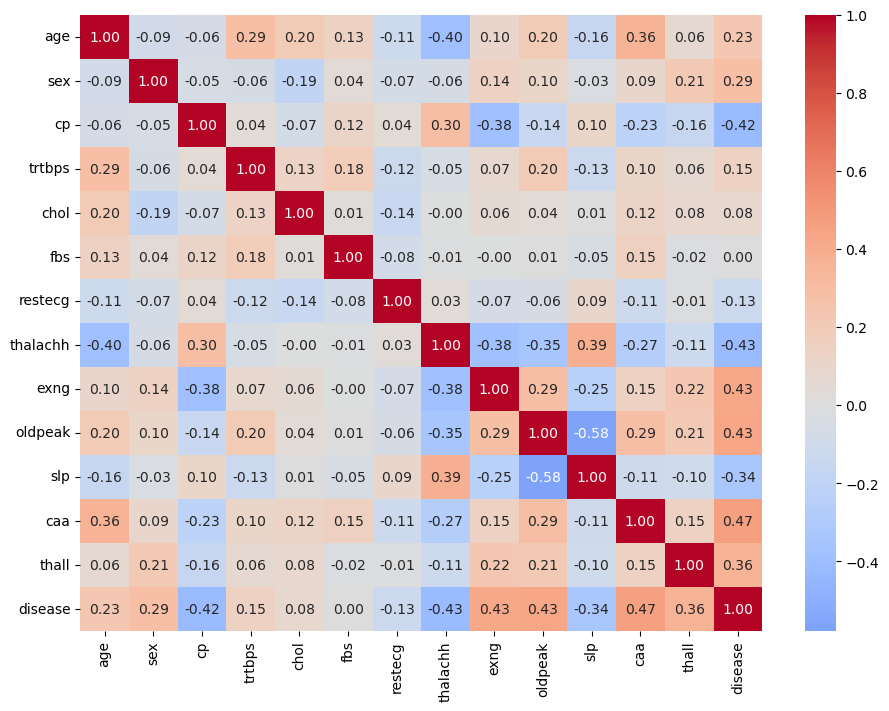

In [30]:
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

In [31]:
df.corr()['disease'].sort_values()

thalachh   -0.426655
cp         -0.423425
slp        -0.337825
restecg    -0.131716
fbs         0.004680
chol        0.076541
trtbps      0.148922
age         0.225453
sex         0.285322
thall       0.364399
exng        0.425085
oldpeak     0.428804
caa         0.467158
disease     1.000000
Name: disease, dtype: float64

In [32]:
pd.crosstab(df['cp'], df['disease'], normalize='index')

disease,0,1
cp,,
0,0.276596,0.723404
1,0.816327,0.183673
2,0.783133,0.216867
3,0.695652,0.304348


Number of blocked vessels (`caa`), chest pain type (`cp`), exercise chest pain (`exng`), oldpeak and max heart rate have the strongest relationships with disease. Cholesterol and fasting blood sugar barely matter on their own, which surprised me.

## 7. Preparing the data

- `cp`, `restecg`, `slp` and `thall` are category labels, not amounts (chest pain type 3 isn't "three times" type 1), so I one-hot encode them.
- `sex`, `fbs` and `exng` are already 0/1, and `caa` is a real count, so they stay as they are.
- 80/20 train/test split. The test set isn't used until the very end.

In [33]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

In [34]:
df = pd.get_dummies(df, columns=['cp', 'restecg', 'slp', 'thall'], drop_first=True, dtype=int)
df.head()

,age,sex,trtbps,chol,fbs,thalachh,exng,oldpeak,caa,disease,cp_1,cp_2,cp_3,restecg_1,restecg_2,slp_1,slp_2,thall_2,thall_3
0,63,1,145,233,1,150,0,2.3,0,0,0,0,1,0,0,0,0,0,0
1,37,1,130,250,0,187,0,3.5,0,0,0,1,0,1,0,0,0,1,0
2,41,0,130,204,0,172,0,1.4,0,0,1,0,0,0,0,0,1,1,0
3,56,1,120,236,0,178,0,0.8,0,0,1,0,0,1,0,0,1,1,0
4,57,0,120,354,0,163,1,0.6,0,0,0,0,0,1,0,0,1,1,0


In [35]:
X = df.drop(columns='disease')
y = df['disease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)

In [36]:
X_train.shape, X_test.shape

((236, 18), (60, 18))

## 8. Comparing models with cross-validation

Logistic regression, SVM and KNN depend on distances or coefficient sizes, so they need scaled features (otherwise cholesterol in the hundreds drowns out oldpeak, which is between 0 and 6). Trees split one feature at a time and don't need scaling.

Putting the scaler in a pipeline means it's fit only on the training part of each fold.

I compare them on:
- **ROC AUC**: how well the model separates sick from healthy patients (1 = perfect, 0.5 = guessing)
- **Recall**: the share of sick patients the model catches. For a medical test, missing a sick patient is worse than a false alarm

In [37]:
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Decision Tree': DecisionTreeClassifier(random_state=1),
    'Random Forest': RandomForestClassifier(random_state=1),
    'SVM': make_pipeline(StandardScaler(), SVC(random_state=1)),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
}

In [38]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

results = []
for name, model in models.items():
    auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    results.append([name, auc.mean(), auc.std(), recall.mean()])

results = pd.DataFrame(results, columns=['model', 'AUC', 'AUC std', 'recall']).sort_values('AUC', ascending=False)
results

,model,AUC,AUC std,recall
0,Logistic Regression,0.914860,0.052167,0.796537
3,SVM,0.910516,0.065107,0.814719
2,Random Forest,0.897194,0.050457,0.823810
4,KNN,0.883053,0.054136,0.777489
1,Decision Tree,0.712061,0.048071,0.712121


Logistic regression (0.91), SVM (0.91), random forest (0.90) and KNN (0.88) are all close. The gaps between them are smaller than the standard deviation (about 0.05), so with ~240 training patients they're basically tied.

The decision tree is clearly worse (0.71). With no depth limit, a single tree memorises the training patients and doesn't generalise. Next I tune the tree (to see if limiting depth fixes it), the random forest and logistic regression.

## 9. Tuning

In [39]:
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=1),
                         {'max_depth': [2, 3, 4, 5], 'min_samples_leaf': [1, 5, 10]},
                         cv=cv, scoring='roc_auc')
tree_grid.fit(X_train, y_train)
tree_grid.best_params_, tree_grid.best_score_

({'max_depth': 4, 'min_samples_leaf': 5}, np.float64(0.8429267399267399))

In [40]:
rf_grid = GridSearchCV(RandomForestClassifier(n_estimators=300, random_state=1),
                       {'max_depth': [3, 5, None], 'min_samples_leaf': [1, 3, 5]},
                       cv=cv, scoring='roc_auc')
rf_grid.fit(X_train, y_train)
rf_grid.best_params_, rf_grid.best_score_

({'max_depth': 5, 'min_samples_leaf': 3}, np.float64(0.907054945054945))

In [41]:
lr_grid = GridSearchCV(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
                       {'logisticregression__C': [0.001, 0.003, 0.01, 0.03, 0.1, 1, 10]},
                       cv=cv, scoring='roc_auc')
lr_grid.fit(X_train, y_train)
lr_grid.best_params_, lr_grid.best_score_

({'logisticregression__C': 0.1}, np.float64(0.919942723942724))

Limiting the tree to depth 4 with at least 5 patients per leaf takes it from 0.71 to 0.84, but it's still the weakest model.

Logistic regression (0.92) and random forest (0.91) end up almost equal. The best `C` for logistic regression is 0.1, a bit stronger regularisation than the default of 1: with this few patients, keeping the model simple helps.

**I choose logistic regression.** It scores the same as the random forest, and every feature gets a coefficient I can explain.

## 10. Final test

In [42]:
final = lr_grid.best_estimator_
pred = final.predict(X_test)
proba = final.predict_proba(X_test)[:, 1]

print('Test AUC:', round(roc_auc_score(y_test, proba), 3))
print(classification_report(y_test, pred, target_names=['healthy', 'disease']))

Test AUC: 0.919
              precision    recall  f1-score   support

     healthy       0.83      0.94      0.88        32
     disease       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



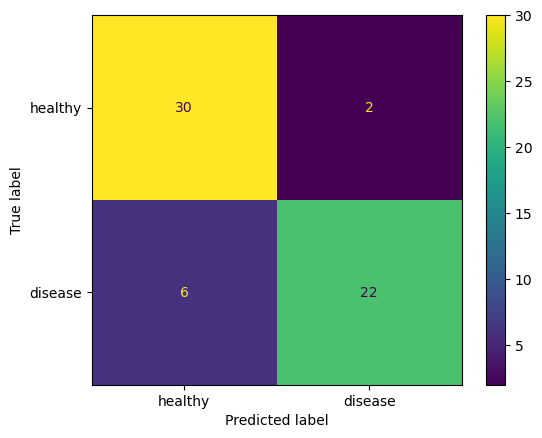

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['healthy', 'disease'])
plt.show()

In [44]:
rf_proba = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]
print('Random forest test AUC:', round(roc_auc_score(y_test, rf_proba), 3))

Random forest test AUC: 0.896


On the 60 test patients: AUC 0.92, accuracy 87%. The model caught 22 of the 28 sick patients (79% recall) and wrongly flagged only 2 of the 32 healthy ones. The random forest scores a bit lower on the test set (AUC 0.90), which supports picking the simpler model.

The test AUC matches the cross-validation AUC (0.92), so the model holds up on patients it has never seen. Recall could be raised by lowering the 0.5 probability threshold, at the cost of more false alarms.

## 11. What the model learned

Because the features were scaled, the coefficient sizes can be compared. Positive = more likely to have heart disease.

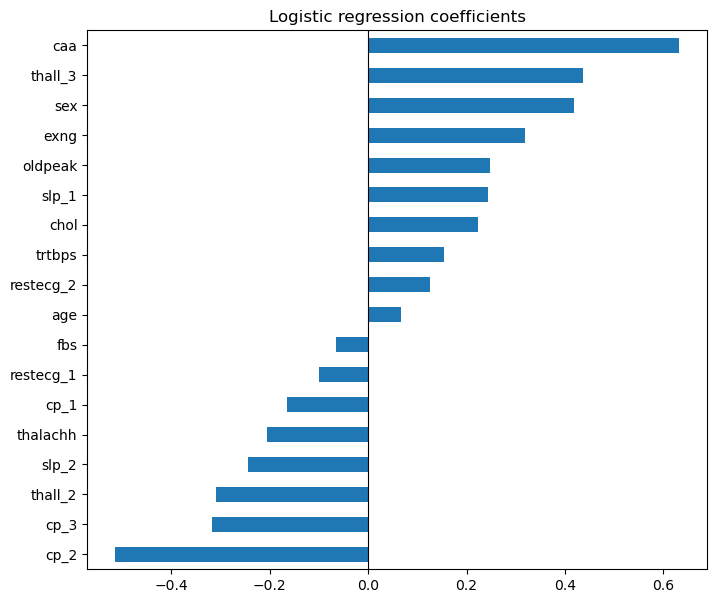

In [45]:
coefs = pd.Series(final.named_steps['logisticregression'].coef_[0], index=X.columns).sort_values()
coefs.plot(kind='barh', figsize=(8, 7))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic regression coefficients')
plt.show()

The biggest risk factors are more blocked vessels (`caa`), a reversible defect on the thallium test (`thall_3`), being male, chest pain during exercise (`exng`) and a higher oldpeak.

Chest pain types 1–3 lower the risk compared to type 0, with type 2 having the largest effect of any feature. Type 0 lines up with the "asymptomatic" group in the UCI data, which had the most heart disease there too. A normal thallium result (`thall_2`) and a higher max heart rate also lower the risk.

Cholesterol gets a moderate positive coefficient even though its correlation with disease on its own was weak (0.08), so it matters more once the other features are accounted for. Age has almost no effect, probably because its effect is already captured by features like blocked vessels and max heart rate.